# Superstore Sales Analysis

Business analyst practice project analyzing the Kaggle Superstore sales dataset. Goal: understand overall performance, trends, and growth, and surface findings a non-technical stakeholder could act on.

See `metadata.py` for the data dictionary.

## 1. Data Loading & Overview

In [58]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#look at data
sales_data = pd.read_csv('data/supermarket_sales.csv')
sales_data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [59]:
sales_data.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


## 2. Data Cleaning

Dropping rows with nulls and converting `Order Date`/`Ship Date` to proper datetime types (source format is day/month/year).

In [60]:
#time to clean
sales_data = sales_data.dropna()
sales_data.shape[0]
sales_data['Order Date'] = pd.to_datetime(sales_data['Order Date'], format='%d/%m/%Y')
sales_data['Ship Date'] = pd.to_datetime(sales_data['Ship Date'], format='%d/%m/%Y')
sales_data.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

## 3. Key Metrics

Headline numbers for the full dataset: total orders, total sales, and total unique customers.

In [61]:
print(f"In total we have received {sales_data['Order ID'].count()} orders.")
print(f"In total we have made sales worth €{sales_data['Sales'].sum():.2f}.")
print(f"In total we have {len(set(sales_data['Customer ID']))} customers.")

In total we have received 9789 orders.
In total we have made sales worth €2252607.41.
In total we have 793 customers.


# Overall Performance

### 1. How has the company performed monthly?

In [19]:
# monthly sales
monthly_sales = sales_data.groupby([sales_data['Order Date'].dt.year.rename('Year'), 
                   sales_data['Order Date'].dt.month.rename('Month')])['Sales'].sum()

monthly_sales = monthly_sales.reset_index()
monthly_sales.columns = ['Year', 'Month', 'Total Sales']
monthly_sales['Month'] = monthly_sales['Month'].map({1:"January", 
                                            2: "February",
                                            3: "March",
                                            4: "April",
                                            5: "May",
                                            6: "June",
                                            7: "July",
                                            8: "August",
                                            9: "September",
                                            10: "October",
                                            11: "November",
                                            12: "December"})
#monthly_sales

/var/folders/hy/pmkvnw454vb37hlh2t41bwsm0000gn/T/ipykernel_77100/4072244802.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  monthly_sales['Date'] = pd.to_datetime(


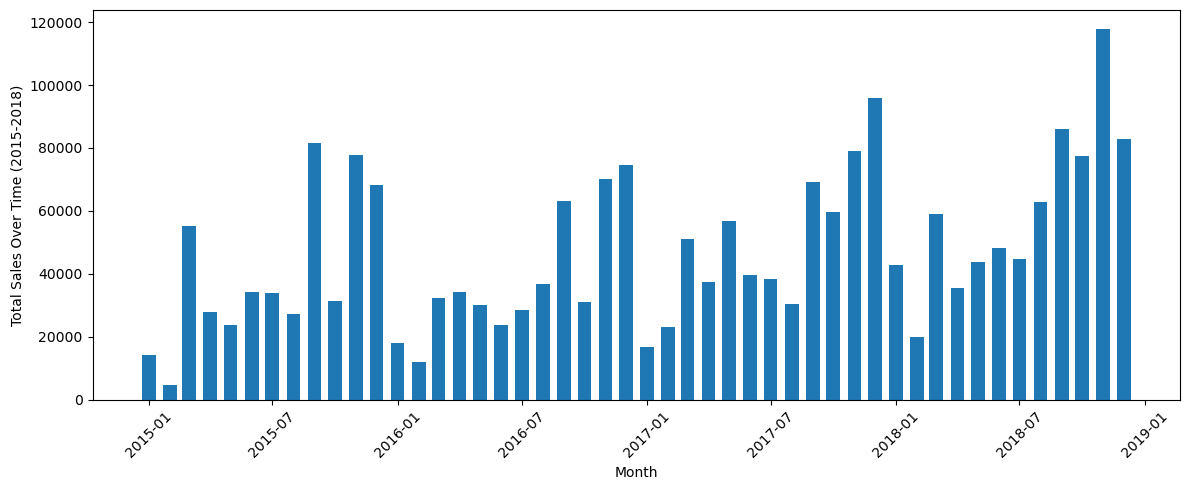

In [ ]:
# Plotting to see trends

monthly_sales['Date'] = pd.to_datetime(
    monthly_sales['Month'].astype(str) + '-' + 
    monthly_sales['Year'].astype(str))

monthly_sales = monthly_sales.sort_values('Date')

plt.figure(figsize=(12,5))
plt.bar(monthly_sales['Date'],monthly_sales['Total Sales'], width=20)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Total Sales Over Time (2015-2018)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

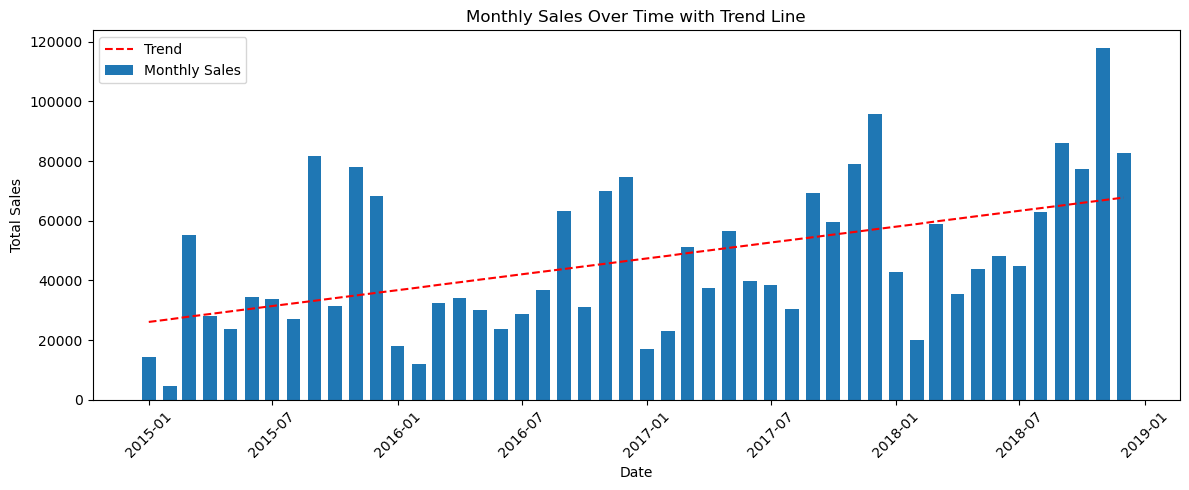

In [78]:
x = np.arange(len(monthly_sales))
y = monthly_sales['Total Sales']
z = np.polyfit(x, y, 1)
trend = np.poly1d(z)

plt.figure(figsize=(12, 5))
plt.bar(monthly_sales['Date'], y, label='Monthly Sales', width=20)
plt.plot(monthly_sales['Date'], trend(x), linestyle='--', color='red', label='Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Over Time with Trend Line')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Month-over-month growth rate, computed from the monthly sales totals above.

In [22]:
# checking monthly growth rate
monthly_sales['Growth'] = monthly_sales['Total Sales'].pct_change().mul(100).round(2)
monthly_sales

,Year,Month,Total Sales,Growth
0,2015,January,14205.7070,NaN
1,2015,February,4519.8920,-68.18
2,2015,March,55205.7970,1121.40
3,2015,April,27906.8550,-49.45
4,2015,May,23644.3030,-15.27
5,2015,June,34322.9356,45.16
6,2015,July,33781.5430,-1.58
7,2015,August,27117.5365,-19.73
8,2015,September,81623.5268,201.00
9,2015,October,31453.3930,-61.47


In [26]:
# averaging monthly growth
average = monthly_sales['Growth'].mean()
print(f'The average monthly growth rate between 2015-2018 is {average:.2f}%')

The average monthly growth rate between 2015-2018 is 40.58%


**Note:** the mean MoM growth rate above is heavily skewed by an early outlier month (Feb→Mar 2015, a ~1121% swing off a very small base) and isn't a reliable "typical growth" figure on its own - see the plot for defensible trends.

### 2. How has the company performed yearly?

In [75]:
# year-to-year growth rate 
yearly_sales = sales_data.groupby(sales_data['Order Date'].dt.year.rename('Year'))['Sales'].count()
yearly_sales = yearly_sales.reset_index()
yearly_sales.columns= ['Year', 'Total Sales']


yearly_sales['Growth'] = yearly_sales['Total Sales'].pct_change().mul(100).round(2)
yearly_sales

,Year,Total Sales,Growth
0,2015,1953,NaN
1,2016,2053,5.12
2,2017,2530,23.23
3,2018,3253,28.58


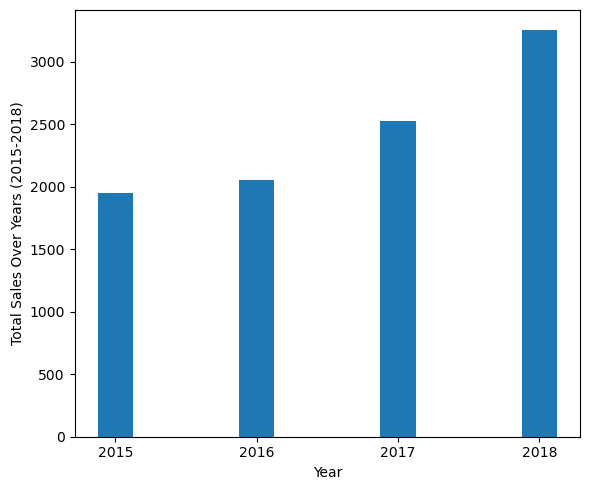

In [31]:
plt.figure(figsize=(6,5))
plt.bar(yearly_sales['Year'],yearly_sales['Total Sales'], width=0.25)
plt.xlabel('Year')
plt.ylabel('Total Sales Over Years (2015-2018)')
plt.xticks(yearly_sales['Year'])
plt.tight_layout()
plt.show()

Comparing total sales in the first year of data vs. the last year gives a more overall "how much did the company grow" picture.

In [32]:
first_year_sales = yearly_sales.iloc[0]['Total Sales']
last_year_sales = yearly_sales.iloc[-1]['Total Sales']

overall_growth = (last_year_sales - first_year_sales) / first_year_sales * 100
print(f'Between the years 2015-2018, the company grew by {overall_growth:.2f}%')

Between the years 2015-2018, the company grew by 66.56%


# Segmentation Analysis

### 1. Sales by region

### 2. Sales by Category and Sub-category

### 3. Top Customers

## Next Steps

- Stage 3: Trend & timing - seasonality, shipping delays
- Stage 4: Forecasting - simple monthly sales forecast (stretch goal)